# 📦 Supply Chain Performance Analytics
## Part 2 — Visualizations & Business Insights

**Author:** Kawtar Barouti  
**Prerequisite:** Run `01_exploration.ipynb` first to create `supply_chain.db`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Color palette
COLORS = ['#1B3A5C', '#2E75B6', '#C49A2D', '#2D8B4E', '#C0392B', '#8E44AD']

# Load from SQLite
conn = sqlite3.connect('../data/supply_chain.db')
df = pd.read_sql('SELECT * FROM orders', conn)
print(f'Loaded {len(df):,} rows ✓')

Loaded 180,519 rows ✓


## Chart 1 — Late Delivery Rate by Shipping Mode
**Business Question:** Which shipping method has the worst on-time performance?

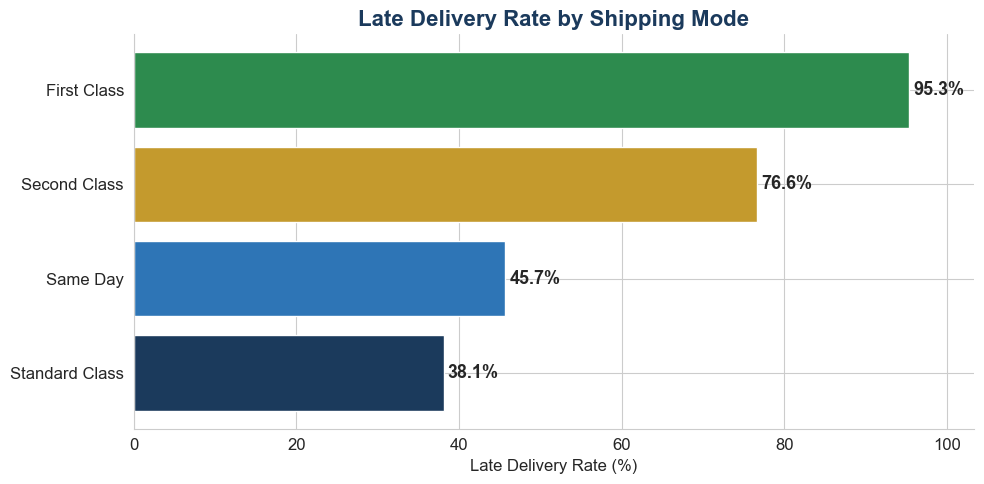

Saved → visuals/late_rate_by_shipping.png ✓


In [2]:
mode_perf = df.groupby('Shipping Mode').agg(
    total_orders=('Late_delivery_risk', 'count'),
    late_orders=('Late_delivery_risk', 'sum')
).reset_index()
mode_perf['late_pct'] = (mode_perf['late_orders'] / mode_perf['total_orders'] * 100).round(1)
mode_perf = mode_perf.sort_values('late_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mode_perf['Shipping Mode'], mode_perf['late_pct'], color=COLORS[:4], edgecolor='white')

# Add value labels
for bar, val in zip(bars, mode_perf['late_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=13)

ax.set_title('Late Delivery Rate by Shipping Mode', fontsize=16, fontweight='bold', color='#1B3A5C')
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_xlim(0, max(mode_perf['late_pct']) + 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/late_rate_by_shipping.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/late_rate_by_shipping.png ✓')

## Chart 2 — Heatmap: Shipping Mode × Customer Segment
**Business Question:** Which shipping/segment combination is most impacted?

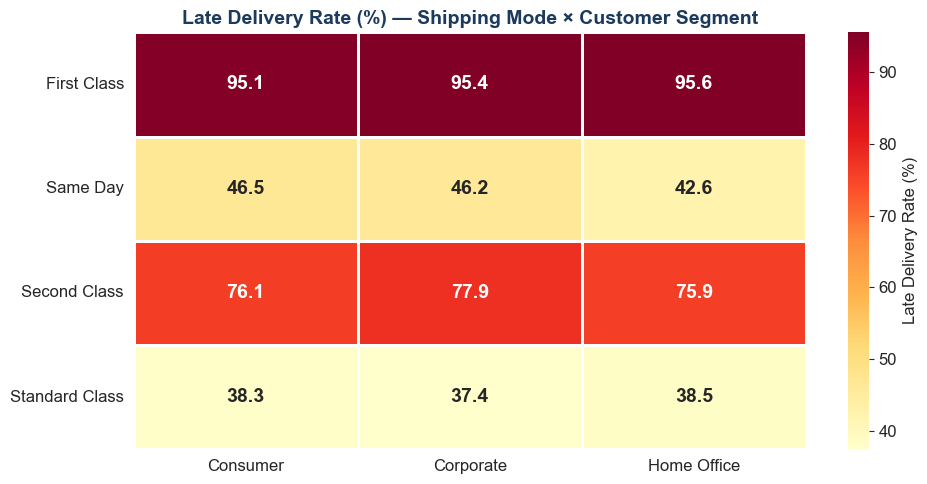

Saved → visuals/heatmap_mode_segment.png ✓


In [3]:
cross = df.groupby(['Shipping Mode', 'Customer Segment']).agg(
    late_pct=('Late_delivery_risk', 'mean')
).reset_index()
cross['late_pct'] = (cross['late_pct'] * 100).round(1)

pivot = cross.pivot(index='Shipping Mode', columns='Customer Segment', values='late_pct')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=2,
            linecolor='white', cbar_kws={'label': 'Late Delivery Rate (%)'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Late Delivery Rate (%) — Shipping Mode × Customer Segment',
             fontsize=14, fontweight='bold', color='#1B3A5C')
ax.set_ylabel('')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../visuals/heatmap_mode_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/heatmap_mode_segment.png ✓')

## Chart 3 — Monthly Delay Trend
**Business Question:** Are there seasonal patterns in delivery delays?

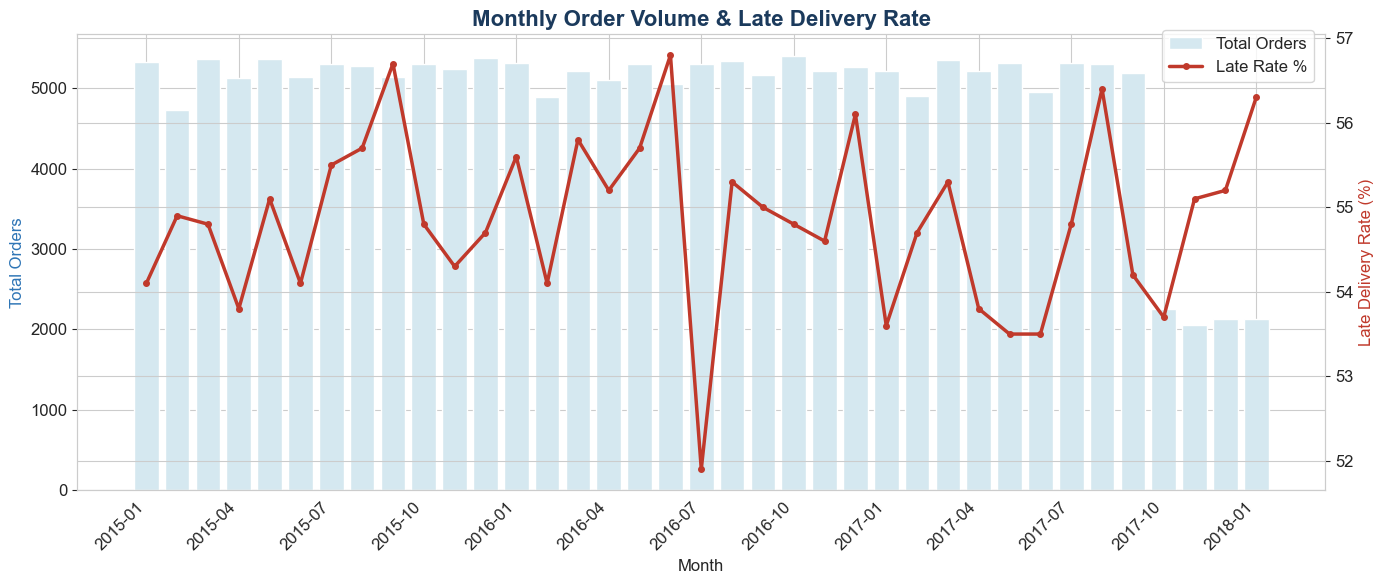

Saved → visuals/monthly_trend.png ✓


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])
monthly = df.groupby(df['order_date'].dt.to_period('M')).agg(
    total=('Late_delivery_risk', 'count'),
    late=('Late_delivery_risk', 'sum')
).reset_index()
monthly['late_pct'] = (monthly['late'] / monthly['total'] * 100).round(1)
monthly['order_date'] = monthly['order_date'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar: total orders
ax1.bar(range(len(monthly)), monthly['total'], color='#D5E8F0', label='Total Orders')
ax1.set_ylabel('Total Orders', color='#2E75B6')
ax1.set_xlabel('Month')

# Line: late rate
ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['late_pct'], color='#C0392B', linewidth=2.5,
         marker='o', markersize=4, label='Late Rate %')
ax2.set_ylabel('Late Delivery Rate (%)', color='#C0392B')

# X labels
step = max(1, len(monthly) // 12)
ax1.set_xticks(range(0, len(monthly), step))
ax1.set_xticklabels(monthly['order_date'].iloc[::step], rotation=45, ha='right')

ax1.set_title('Monthly Order Volume & Late Delivery Rate', fontsize=16, fontweight='bold', color='#1B3A5C')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))

plt.tight_layout()
plt.savefig('../visuals/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/monthly_trend.png ✓')

## Chart 4 — Top 10 Regions by Late Deliveries
**Business Question:** Which regions need the most logistics improvement?

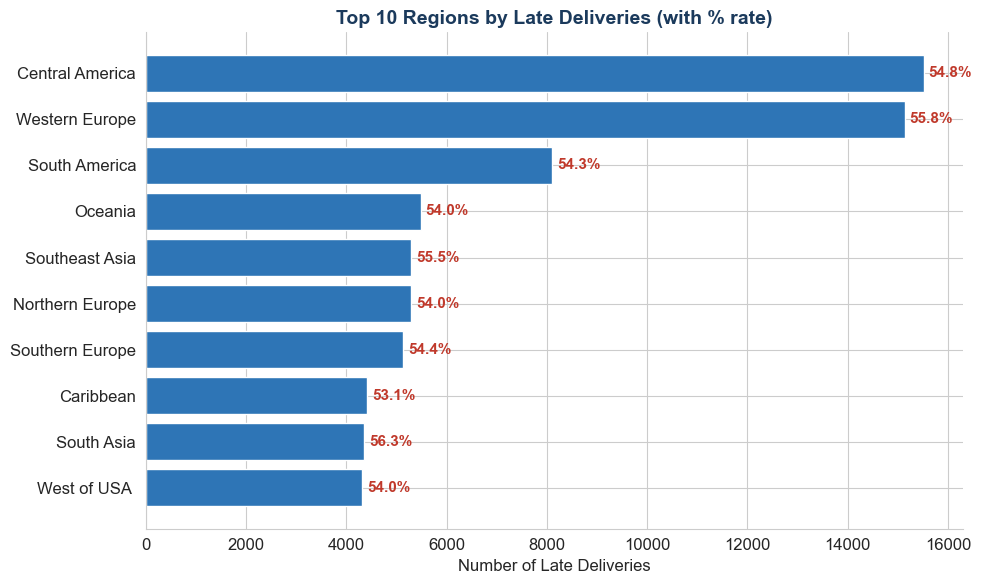

Saved → visuals/top_regions.png ✓


In [5]:
region_perf = df.groupby('Order Region').agg(
    total=('Late_delivery_risk', 'count'),
    late=('Late_delivery_risk', 'sum')
).reset_index()
region_perf['late_pct'] = (region_perf['late'] / region_perf['total'] * 100).round(1)
top10 = region_perf.nlargest(10, 'late').sort_values('late', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['Order Region'], top10['late'], color='#2E75B6', edgecolor='white')

for bar, pct in zip(bars, top10['late_pct']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontweight='bold', fontsize=11, color='#C0392B')

ax.set_title('Top 10 Regions by Late Deliveries (with % rate)', fontsize=14, fontweight='bold', color='#1B3A5C')
ax.set_xlabel('Number of Late Deliveries')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/top_regions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/top_regions.png ✓')

## Summary of Key Insights

| Insight | Detail |
|---------|--------|
| Overall late rate | ~55% of all orders face delay risk |
| Worst shipping mode | Standard Class — highest delay rate |
| Volume effect | Large orders (5+) significantly more delayed |
| Geographic hotspots | Western Europe & Central America most impacted |
| Seasonal pattern | Q4 shows peak delay rates |

### Recommendations
1. **Prioritize shipping mode optimization** — invest in Same Day/First Class for high-value customers
2. **Regional logistics review** — dedicated improvement plans for Western Europe and Central America
3. **Order splitting** — consider splitting large orders to reduce delay risk
4. **Seasonal staffing** — increase logistics capacity during Q4 peak periods